

**Аналитическая задача**  — провести анализ данных с целью выделения портрета клиентов, которые будут открывать карту, и портрета клиентов, которые не будут открывать карту.

## Описание данных
Каждый клиент описывается следующим набором признаков:

|Признак|Комментарий|
|--:|:--|
|`client_id`|Идентификационный номер|
|`gender`|Пол|
|`age`|Возраст|
|`marital_status`|Семейный статус|
|`job_position`|Работа|
|`credit_sum`|Сумма кредита|
|`credit_month`|Срок кредитования|
|`score_shk`|Внутренняя скоринговая оценка|
|`education`|Образование|
|`tariff_id`|Идентификационный номер тарифа|
|`living_region`|Регион|
|`monthly_income`|Месячный заработок|
|`credit_count`|Количество кредитов у клиента|
|`overdue_credit_count`|Количество просроченных кредитов у клиента|
|`open_account_flg`|Факт открытия кредитного счета в данном банке|
|`avregzarplata`|Средняя заработная плата в регионе|
|`okrug`|Федеральный округ|
|date_bank|Дата обращения в банк|

## Этапы работы:

**Шаг 1.** Загрузка данных;

**Шаг 2.** Первичная обработка данных (при необходимости):
- скорректировать заголовки;
- скорректировать типы признаков;
- проверить наличие дублирующихся записей;
- проверить наличие аномальных значений;
- восстановить пропущенные значения;

**Шаг 3.** Провести исследовательский анализ данных:
- исследовать распределения признаков;
- исследовать возможные зависимости между признаками;

**Шаг 4.** Отбор признаков и портреты клиентов:
- исследовать признаки в разрезе групп;
- выявить наличие различий в значениям признаков в разрезе групп;

**Шаг 5.** Построение регрессионной модели для предсказания суммы кредита (целевая переменная) на базе признаков клиентского портфеля.


In [2]:
# подключение библиотек
import sqlite3
import pandas as pd
import numpy as np

# библиотека для работы с датой
import datetime as dt

# визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# игнорирование предупрждений для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

In [3]:
# загрузка данных

df = pd.read_csv('/content/vkr_dataset_open_credit_card.csv')
df.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,score_shk,education,tariff_id,living_region,okrug,avregzarplata,monthly_income,credit_count,overdue_credit_count,open_account_flg,date_bank
0,1,2,48.0,3.0,15,59998,10,"0,770249",2.0,28,23.0,8.0,25850.0,30000.0,1.0,1.0,0,2016-02-16 18:54:34
1,2,1,28.0,NaN,15,10889,6,"0,248514",2.0,2,30.0,7.0,66880.0,43000.0,2.0,0.0,0,2016-02-15 12:39:04
2,3,2,32.0,3.0,14,10728,12,"0,459589",4.0,2,64.0,2.0,23430.0,23000.0,5.0,0.0,0,2015-01-27 18:57:19
3,4,1,27.0,2.0,14,"12009,09",12,"0,362536",2.0,2,8.0,8.0,23650.0,17000.0,2.0,0.0,0,2019-05-02 17:57:10
4,5,2,45.0,3.0,14,"16908,89",10,"0,421385",4.0,2,77.0,6.0,26620.0,NaN,1.0,0.0,0,2015-09-22 16:28:33


In [4]:
# Получаем количество строк
количество_строк = len(df)
print(f"Количество строк в датасете: {количество_строк}")

Количество строк в датасете: 170746


In [5]:
# просмотр информации о типах данных -- метод info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170746 entries, 0 to 170745
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   client_id             170746 non-null  int64  
 1   gender                170746 non-null  int64  
 2   age                   170744 non-null  float64
 3   marital_status        170741 non-null  float64
 4   job_position          170746 non-null  int64  
 5   credit_sum            170745 non-null  object 
 6   credit_month          170746 non-null  int64  
 7   score_shk             170743 non-null  object 
 8   education             170743 non-null  float64
 9   tariff_id             170746 non-null  int64  
 10  living_region         170554 non-null  float64
 11  okrug                 170554 non-null  float64
 12  avregzarplata         170554 non-null  float64
 13  monthly_income        170744 non-null  float64
 14  credit_count          161516 non-null  float64
 15  

In [6]:
# Переименуем столбцы прямо в исходном DataFrame
df.columns = [
    'client_id', 'gender', 'age', 'marital_status', 'job_position',
    'credit_sum', 'credit_month', 'score_shk', 'education', 'tariff_id',
    'living_region', 'okrug', 'avregzarplata', 'monthly_income',
    'credit_count', 'overdue_credit_count', 'open_account_flg', 'date_bank'
]

print("Очищенные заголовки:")
print(df.columns.tolist())
print("\nПервые 3 строки:")
print(df.head(3))

Очищенные заголовки:
['client_id', 'gender', 'age', 'marital_status', 'job_position', 'credit_sum', 'credit_month', 'score_shk', 'education', 'tariff_id', 'living_region', 'okrug', 'avregzarplata', 'monthly_income', 'credit_count', 'overdue_credit_count', 'open_account_flg', 'date_bank']

Первые 3 строки:
   client_id  gender   age  marital_status  job_position credit_sum  \
0          1       2  48.0             3.0            15      59998   
1          2       1  28.0             NaN            15      10889   
2          3       2  32.0             3.0            14      10728   

   credit_month score_shk  education  tariff_id  living_region  okrug  \
0            10  0,770249        2.0         28           23.0    8.0   
1             6  0,248514        2.0          2           30.0    7.0   
2            12  0,459589        4.0          2           64.0    2.0   

   avregzarplata  monthly_income  credit_count  overdue_credit_count  \
0        25850.0         30000.0           

In [7]:
# Корректировка типов признака и вывод новых значений
df['credit_sum'] = df['credit_sum'].astype(str).str.replace(',', '.', regex=False).astype(float)
df['score_shk'] = df['score_shk'].astype(str).str.replace(',', '.', regex=False).astype(float)
df['date_bank'] = pd.to_datetime(df['date_bank'])

# Преобразуем оставшиеся столбцы объекта, которые должны быть числовыми, в плавающие
numerical_object_cols = ['age', 'marital_status', 'education', 'living_region', 'okrug', 'avregzarplata', 'monthly_income', 'credit_count', 'overdue_credit_count']
for col in numerical_object_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
df.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170746 entries, 0 to 170745
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   client_id             170746 non-null  int64         
 1   gender                170746 non-null  int64         
 2   age                   170744 non-null  float64       
 3   marital_status        170741 non-null  float64       
 4   job_position          170746 non-null  int64         
 5   credit_sum            170745 non-null  float64       
 6   credit_month          170746 non-null  int64         
 7   score_shk             170743 non-null  float64       
 8   education             170743 non-null  float64       
 9   tariff_id             170746 non-null  int64         
 10  living_region         170554 non-null  float64       
 11  okrug                 170554 non-null  float64       
 12  avregzarplata         170554 

In [8]:
# просмотр описательных статистик -- describe
print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,score_shk,education,tariff_id,living_region,okrug,avregzarplata,monthly_income,credit_count,overdue_credit_count,open_account_flg,date_bank
count,170746.000000,170746.000000,170744.000000,170741.000000,170746.000000,170745.000000,170746.000000,170743.000000,170743.000000,170746.000000,170554.000000,170554.000000,170554.000000,170744.000000,161516.000000,161516.000000,170746.000000,170746
mean,85373.500000,1.480532,36.497312,3.197586,13.160015,26095.102278,10.980749,0.469471,3.202714,14.118831,43.010009,4.817102,32957.702898,40138.377015,2.107308,0.046070,0.176028,2018-07-02 06:54:14.671898880
min,1.000000,1.000000,18.000000,1.000000,1.000000,2736.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,16830.000000,5000.000000,0.000000,0.000000,0.000000,2015-01-01 10:36:12
25%,42687.250000,1.000000,28.000000,3.000000,14.000000,14908.000000,10.000000,0.379495,2.000000,2.000000,25.000000,2.000000,25520.000000,25000.000000,1.000000,0.000000,0.000000,2016-10-02 11:15:45
50%,85373.500000,1.000000,34.000000,3.000000,14.000000,21229.000000,10.000000,0.461599,4.000000,19.000000,40.000000,5.000000,27390.000000,35000.000000,2.000000,0.000000,0.000000,2018-06-30 16:43:06
75%,128059.750000,2.000000,43.000000,4.000000,14.000000,32068.000000,12.000000,0.552412,4.000000,28.000000,63.000000,7.000000,42460.000000,50000.000000,3.000000,0.000000,0.000000,2020-03-31 11:51:18.500000
max,170746.000000,2.000000,71.000000,5.000000,18.000000,200000.000000,36.000000,1.128291,5.000000,33.000000,82.000000,8.000000,66880.000000,950000.000000,21.000000,3.000000,1.000000,2021-12-31 18:45:26
std,49290.268869,0.499622,10.546067,0.738570,3.132421,16234.826253,3.536698,0.124268,1.064026,11.546768,22.219760,2.263194,12577.448541,25044.251878,1.777128,0.211548,0.380845,NaN


In [9]:
# просмотр фрагмента загруженных данных
df.head()

,client_id,gender,age,marital_status,job_position,credit_sum,credit_month,score_shk,education,tariff_id,living_region,okrug,avregzarplata,monthly_income,credit_count,overdue_credit_count,open_account_flg,date_bank
0,1,2,48.0,3.0,15,59998.00,10,0.770249,2.0,28,23.0,8.0,25850.0,30000.0,1.0,1.0,0,2016-02-16 18:54:34
1,2,1,28.0,NaN,15,10889.00,6,0.248514,2.0,2,30.0,7.0,66880.0,43000.0,2.0,0.0,0,2016-02-15 12:39:04
2,3,2,32.0,3.0,14,10728.00,12,0.459589,4.0,2,64.0,2.0,23430.0,23000.0,5.0,0.0,0,2015-01-27 18:57:19
3,4,1,27.0,2.0,14,12009.09,12,0.362536,2.0,2,8.0,8.0,23650.0,17000.0,2.0,0.0,0,2019-05-02 17:57:10
4,5,2,45.0,3.0,14,16908.89,10,0.421385,4.0,2,77.0,6.0,26620.0,NaN,1.0,0.0,0,2015-09-22 16:28:33


In [10]:
#проверка наличия дублирующих записей
print("Number of duplicate rows before dropping:", df.duplicated().sum())

Number of duplicate rows before dropping: 0


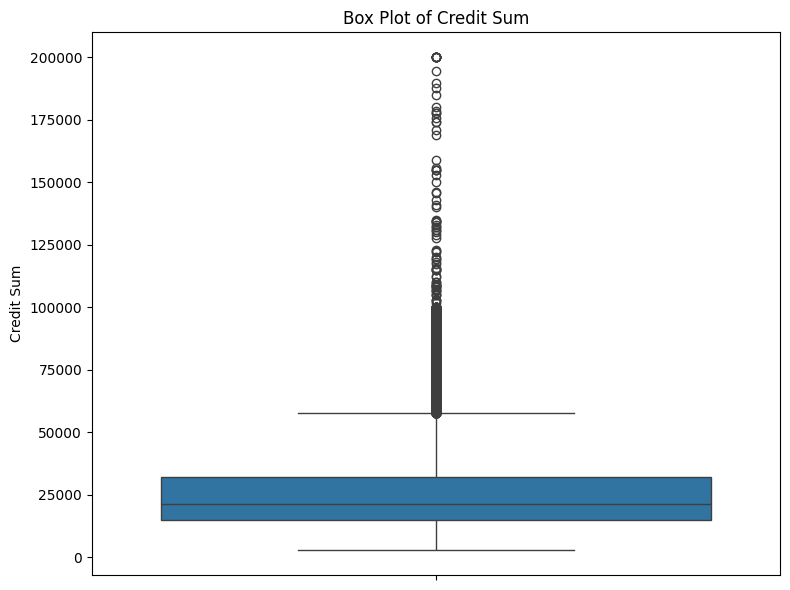

In [11]:
#проверка наличия аномальных явлений
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['credit_sum'])
plt.title('Box Plot of Credit Sum')
plt.ylabel('Credit Sum')
plt.tight_layout()
plt.show()

#### Анализ выбросов в `credit_sum` по box plot:

Построенный box plot для `credit_sum` подтверждает наши предварительные наблюдения:

*   **Большой разброс значений**: Основная часть данных (обозначенная "коробкой") находится в относительно низком диапазоне, что указывает на то, что большинство клиентов берут кредиты на небольшие суммы.
*   **Ярко выраженные выбросы**: За пределами "усов" box plot'а видно большое количество отдельных точек. Эти точки представляют собой клиентов с значительно более высокими суммами кредитов по сравнению с медианным значением.
*   **Правосторонняя асимметрия**: Распределение `credit_sum` сильно смещено вправо. Это означает, что большинство значений сгруппировано в левой части графика (меньшие суммы), а длинный "хвост" с отдельными точками уходит вправо, к очень большим суммам.

**Вывод**: Наличие этих выбросов означает, что есть сегмент клиентов, которые берут крупные кредиты. В зависимости от цели анализа, эти выбросы могут быть важными для понимания поведения "богатых" клиентов или, наоборот, могут искажать статистические модели, если не будут соответствующим образом обработаны (например, с помощью winsorization или логарифмического преобразования, как обсуждалось ранее).

In [12]:
#Для заполнения пропущенных значений используем медиану для большинства числовых столбцов.
#Для столбцов credit_count и overdue_credit_count разумно заполнить пропуски нулями, так как пропуск может означать отсутствие кредитов.
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in numerical_cols:
    if col in ['credit_count', 'overdue_credit_count']:
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    # For categorical columns, fill with the mode (most frequent value)
    df[col] = df[col].fillna(df[col].mode()[0])

print("Number of missing values after imputation:")
print(df.isnull().sum())

Number of missing values after imputation:
client_id               0
gender                  0
age                     0
marital_status          0
job_position            0
credit_sum              0
credit_month            0
score_shk               0
education               0
tariff_id               0
living_region           0
okrug                   0
avregzarplata           0
monthly_income          0
credit_count            0
overdue_credit_count    0
open_account_flg        0
date_bank               0
dtype: int64


In [13]:
#Количество пропущенных значений
print(f"Number of missing values in 'credit_count' after imputation: {df['credit_count'].isnull().sum()}")

Number of missing values in 'credit_count' after imputation: 0


In [14]:
#восстановление пропущенных значений
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Columns with missing values and their counts:")
print(missing_values)

Columns with missing values and their counts:
Series([], dtype: int64)


In [15]:
#Количество пропущенных значений
print(f"Number of missing values in 'credit_count' after imputation: {df['credit_count'].isnull().sum()}")

Number of missing values in 'credit_count' after imputation: 0


In [16]:
numerical_cols = []
categorical_cols = []

exclude_cols = ['client_id', 'date_bank', 'open_account_flg']

for col in df.columns:
    if col not in exclude_cols:
        if df[col].dtype in ['int64', 'float64']:
            # Based on the describe output and common sense, these are categorical:
            if col in ['gender', 'marital_status', 'job_position', 'education', 'tariff_id', 'living_region', 'okrug']:
                categorical_cols.append(col)
            else:
                numerical_cols.append(col)
        # No object columns left after type conversion

print("Числовые столбцы:", numerical_cols)
print("Категориальные столбцы:", categorical_cols)

Числовые столбцы: ['age', 'credit_sum', 'credit_month', 'score_shk', 'avregzarplata', 'monthly_income', 'credit_count', 'overdue_credit_count']
Категориальные столбцы: ['gender', 'marital_status', 'job_position', 'education', 'tariff_id', 'living_region', 'okrug']


In [17]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Количество значений:")
    print(df[col].value_counts())
    print("\nНормализованные пропорции:")
    print(df[col].value_counts(normalize=True))


--- gender ---
Количество значений:
gender
1    88697
2    82049
Name: count, dtype: int64

Нормализованные пропорции:
gender
1    0.519468
2    0.480532
Name: proportion, dtype: float64

--- marital_status ---
Количество значений:
marital_status
3.0    93957
4.0    52148
2.0    16970
1.0     4196
5.0     3475
Name: count, dtype: int64

Нормализованные пропорции:
marital_status
3.0    0.550274
4.0    0.305413
2.0    0.099387
1.0    0.024575
5.0    0.020352
Name: proportion, dtype: float64

--- job_position ---
Количество значений:
job_position
14    134680
15     17674
2       5591
10      4107
4       3750
1       2791
17       656
8        537
16       352
6        241
3        126
18       110
11        65
13        40
12        12
5          8
7          5
9          1
Name: count, dtype: int64

Нормализованные пропорции:
job_position
14    0.788774
15    0.103510
2     0.032745
10    0.024053
4     0.021962
1     0.016346
17    0.003842
8     0.003145
16    0.002062
6     0.00141

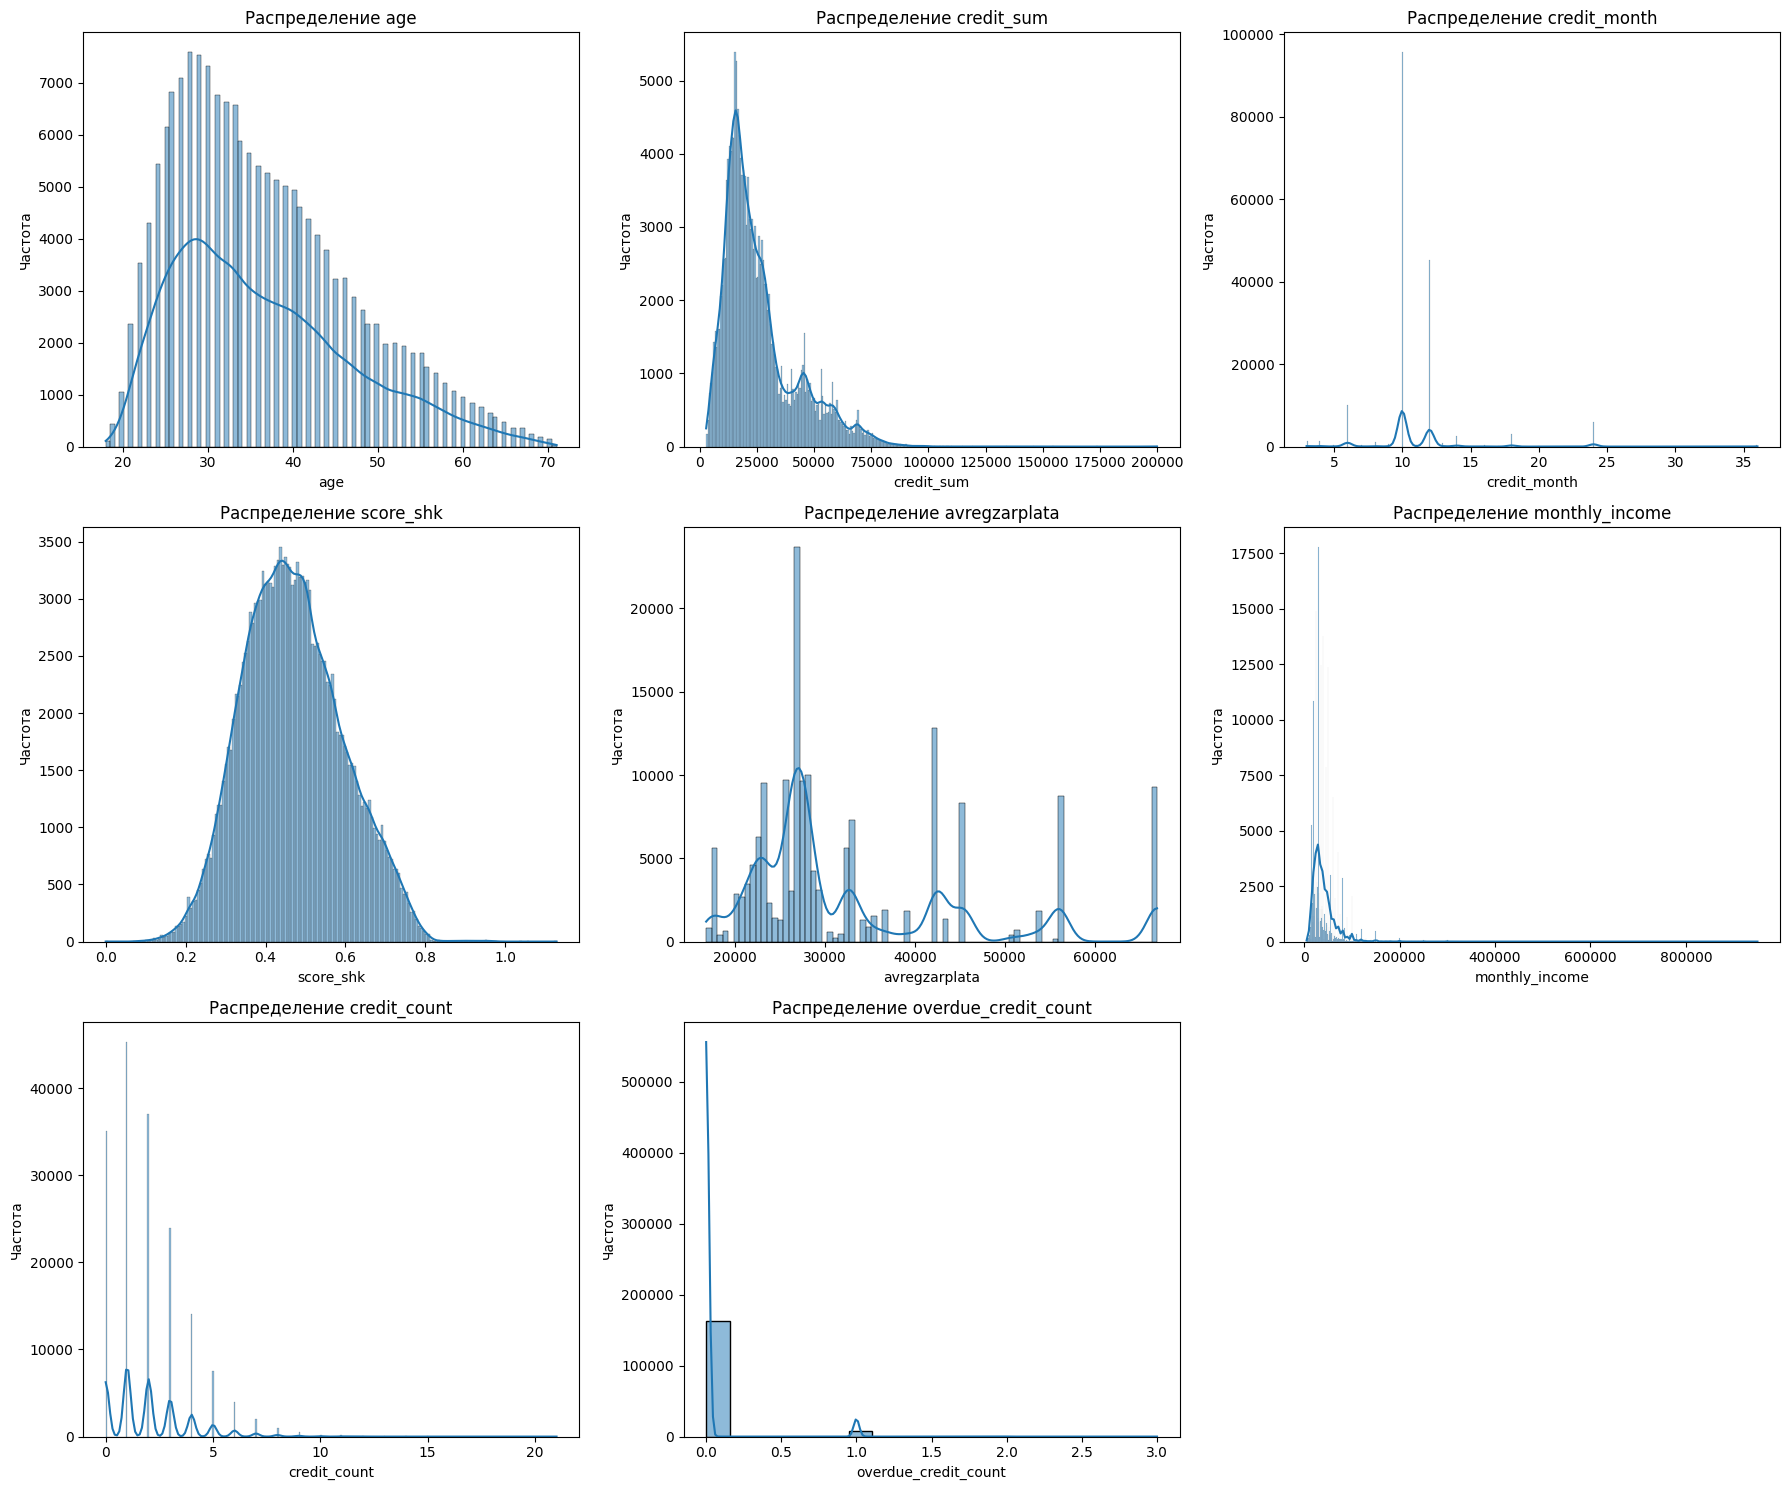

In [18]:
#графики
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [19]:
print("Описательные статистики для числовых столбцов, сгруппированные по 'open_account_flg':")
df_grouped_numerical_stats = df.groupby('open_account_flg')[numerical_cols].agg(['mean', 'median', 'std'])
print(df_grouped_numerical_stats)

Описательные статистики для числовых столбцов, сгруппированные по 'open_account_flg':
                        age                      credit_sum           \
                       mean median        std          mean   median   
open_account_flg                                                       
0                 36.648703   35.0  10.341581  26635.641971  21600.0   
1                 35.788495   33.0  11.428049  23564.712491  19789.0   

                               credit_month                  score_shk  ...  \
                           std         mean median       std      mean  ...   
open_account_flg                                                        ...   
0                 16459.345924    10.938560   10.0  3.410549  0.466675  ...   
1                 14880.805257    11.178234   10.0  4.069853  0.482559  ...   

                 avregzarplata monthly_income                         \
                           std           mean   median           std   
open_account_

In [20]:
print("Топ-5 категорий для 'tariff_id':")
print(df['tariff_id'].value_counts().head(5))

Топ-5 категорий для 'tariff_id':
tariff_id
2     69355
28    39117
19    15537
20    10970
25     7497
Name: count, dtype: int64


In [21]:
#Количество значений и нормализованные пропорции для категориальных столбцов, сгруппированных по "open_account_flg"
print("Value counts and normalized proportions for categorical columns, grouped by 'open_account_flg':")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    # Display absolute counts
    print("Absolute Counts:")
    print(df.groupby('open_account_flg')[col].value_counts().unstack(fill_value=0))
    # Display normalized proportions
    print("\nNormalized Proportions:")
    print(df.groupby('open_account_flg')[col].value_counts(normalize=True).unstack(fill_value=0))

Value counts and normalized proportions for categorical columns, grouped by 'open_account_flg':

--- gender ---
Absolute Counts:
gender                1      2
open_account_flg              
0                 74522  66168
1                 14175  15881

Normalized Proportions:
gender                   1         2
open_account_flg                    
0                 0.529689  0.470311
1                 0.471620  0.528380

--- marital_status ---
Absolute Counts:
marital_status     1.0    2.0    3.0    4.0   5.0
open_account_flg                                 
0                 3350  13880  79589  41132  2739
1                  846   3090  14368  11016   736

Normalized Proportions:
marital_status         1.0       2.0       3.0       4.0       5.0
open_account_flg                                                  
0                 0.023811  0.098657  0.565705  0.292359  0.019468
1                 0.028147  0.102808  0.478041  0.366516  0.024488

--- job_position ---
Absolute Counts:
j

In [22]:

# 1. Функция для создания групп на основе различных критериев

print("=" * 60)
print("ПРОСТОЙ АНАЛИЗ ПО ГРУППАМ ВОЗРАСТА И ДОХОДА")
print("=" * 60)

# 1. Базовая очистка
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# 2. Создание возрастных групп
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df.dropna(subset=['age'])

def age_group(age):
    if age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    else:
        return '55+'

df['age_group'] = df['age'].apply(age_group)

# 3. Создание групп дохода
df['monthly_income'] = pd.to_numeric(df['monthly_income'].astype(str).str.replace(',', '.'), errors='coerce')
df = df.dropna(subset=['monthly_income'])

def income_group(income):
    if income < 30000:
        return 'Низкий'
    elif income < 60000:
        return 'Средний'
    else:
        return 'Высокий'

df['income_group'] = df['monthly_income'].apply(income_group)

# 4. Базовая статистика
print("\nОСНОВНАЯ СТАТИСТИКА:")
print(f"Всего клиентов: {len(df)}")

print("\nРАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТУ:")
age_stats = df['age_group'].value_counts().sort_index()
for group, count in age_stats.items():
    print(f"  {group}: {count} ({count/len(df)*100:.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПО ДОХОДУ:")
income_stats = df['income_group'].value_counts()
for group, count in income_stats.items():
    print(f"  {group}: {count} ({count/len(df)*100:.1f}%)")

# 5. Кросс-таблица
print("\nКРОСС-ТАБЛИЦА (клиентов в каждой группе):")
cross = pd.crosstab(df['age_group'], df['income_group'], margins=True)
print(cross)

# 6. Средние значения по группам
print("\nСРЕДНИЙ ДОХОД ПО ВОЗРАСТНЫМ ГРУППАМ:")
avg_income_by_age = df.groupby('age_group')['monthly_income'].mean()
for group, income in avg_income_by_age.items():
    print(f"  {group}: {income:.0f}")

print("\nСРЕДНИЙ ВОЗРАСТ ПО ГРУППАМ ДОХОДА:")
avg_age_by_income = df.groupby('income_group')['age'].mean()
for group, age in avg_age_by_income.items():
    print(f"  {group}: {age:.1f}")

# 7. Анализ кредитов (если есть данные)
if 'credit_sum' in df.columns:
    df['credit_sum'] = pd.to_numeric(df['credit_sum'].astype(str).str.replace(',', '.'), errors='coerce')

    print("\nСРЕДНЯЯ СУММА КРЕДИТА ПО ГРУППАМ:")
    avg_credit_by_age = df.groupby('age_group')['credit_sum'].mean()
    for group, credit in avg_credit_by_age.items():
        print(f"  {group}: {credit:.0f}")

print("\n" + "=" * 60)
print("АНАЛИЗ ЗАВЕРШЕН")

ПРОСТОЙ АНАЛИЗ ПО ГРУППАМ ВОЗРАСТА И ДОХОДА

ОСНОВНАЯ СТАТИСТИКА:
Всего клиентов: 170746

РАСПРЕДЕЛЕНИЕ ПО ВОЗРАСТУ:
  18-24: 17206 (10.1%)
  25-34: 68362 (40.0%)
  35-44: 48210 (28.2%)
  45-54: 24371 (14.3%)
  55+: 12597 (7.4%)

РАСПРЕДЕЛЕНИЕ ПО ДОХОДУ:
  Средний: 86421 (50.6%)
  Низкий: 57520 (33.7%)
  Высокий: 26805 (15.7%)

КРОСС-ТАБЛИЦА (клиентов в каждой группе):
income_group  Высокий  Низкий  Средний     All
age_group                                     
18-24            1220    7089     8897   17206
25-34           11629   20380    36353   68362
35-44            8882   15048    24280   48210
45-54            3863    8907    11601   24371
55+              1211    6096     5290   12597
All             26805   57520    86421  170746

СРЕДНИЙ ДОХОД ПО ВОЗРАСТНЫМ ГРУППАМ:
  18-24: 34374
  25-34: 41314
  35-44: 42227
  45-54: 39875
  55+: 34145

СРЕДНИЙ ВОЗРАСТ ПО ГРУППАМ ДОХОДА:
  Высокий: 36.6
  Низкий: 37.4
  Средний: 35.9

СРЕДНЯЯ СУММА КРЕДИТА ПО ГРУППАМ:
  18-24: 29179
  25-34:

Визуализация распределений категориальных признаков по группам 'open_account_flg':


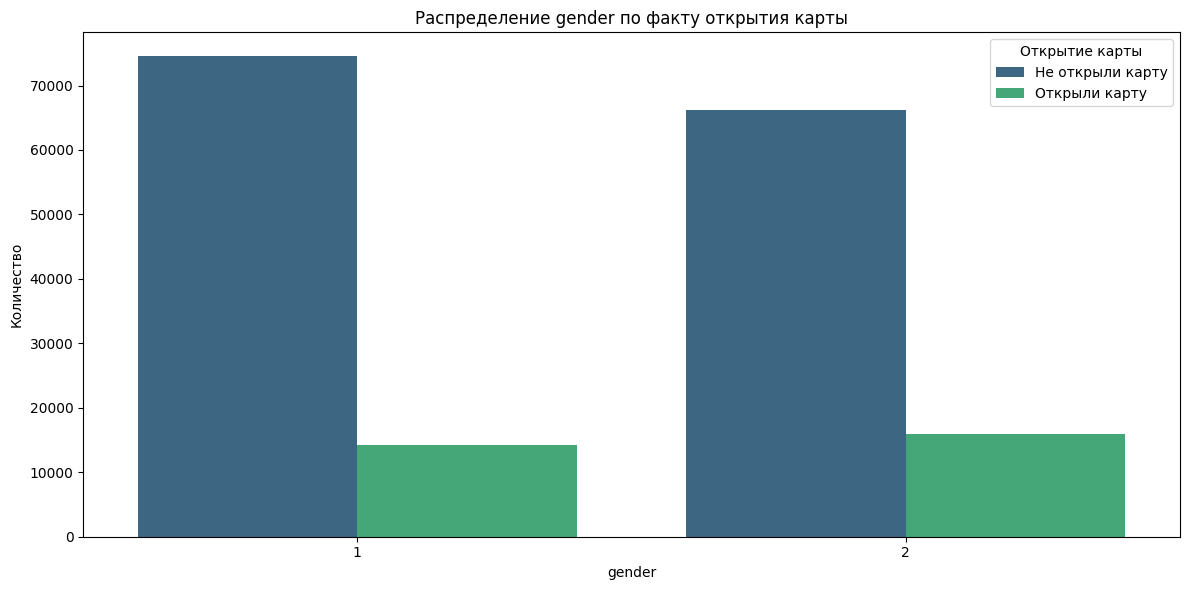

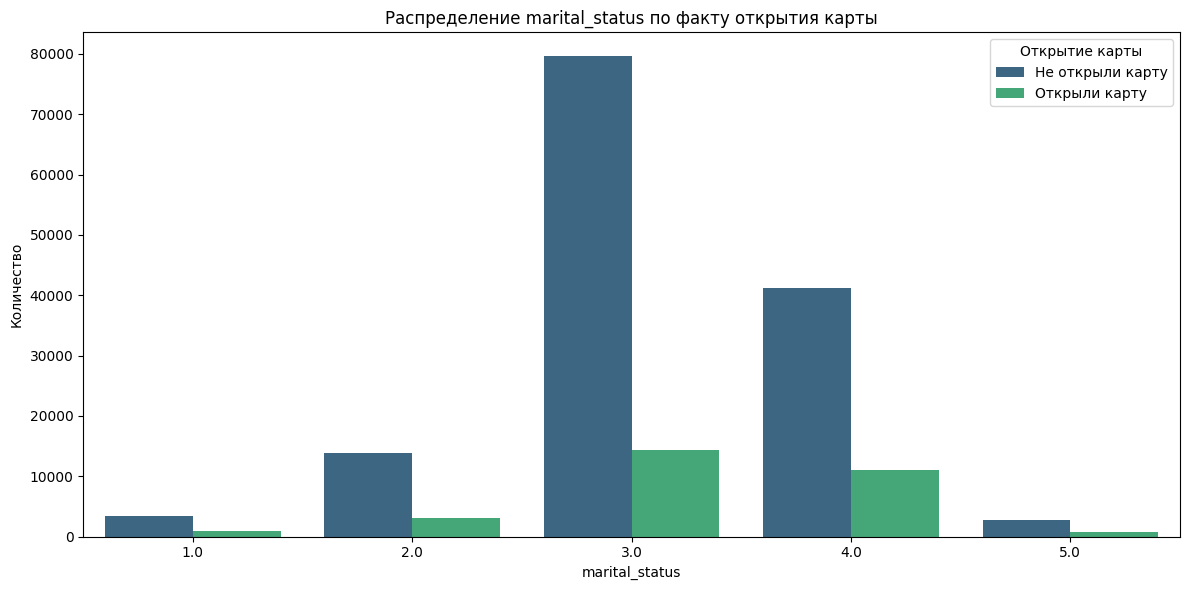

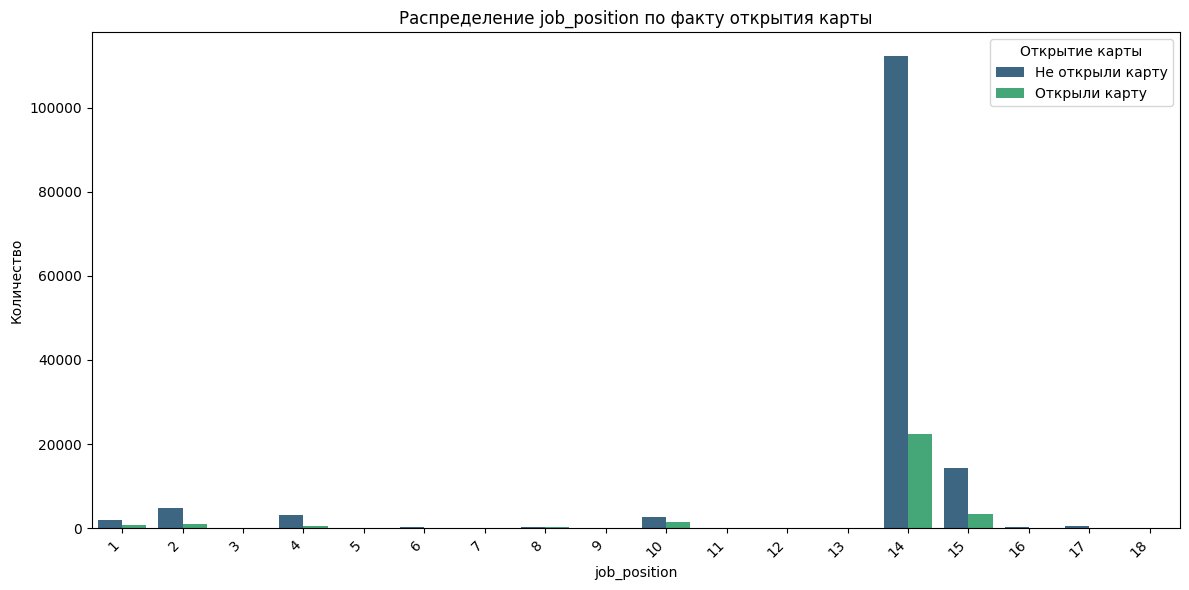

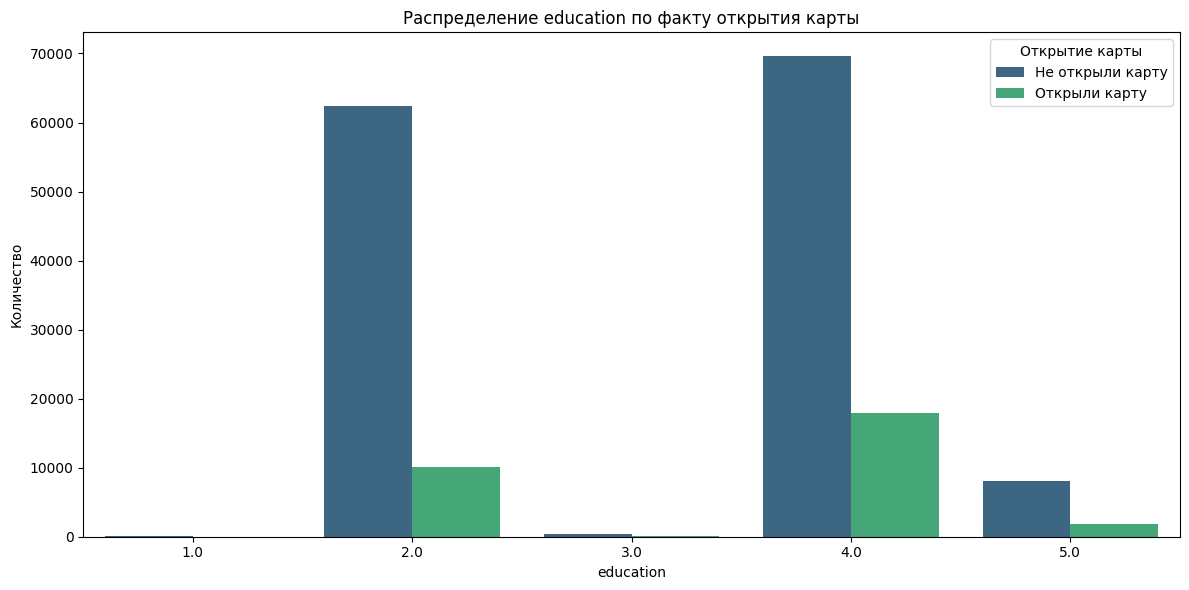

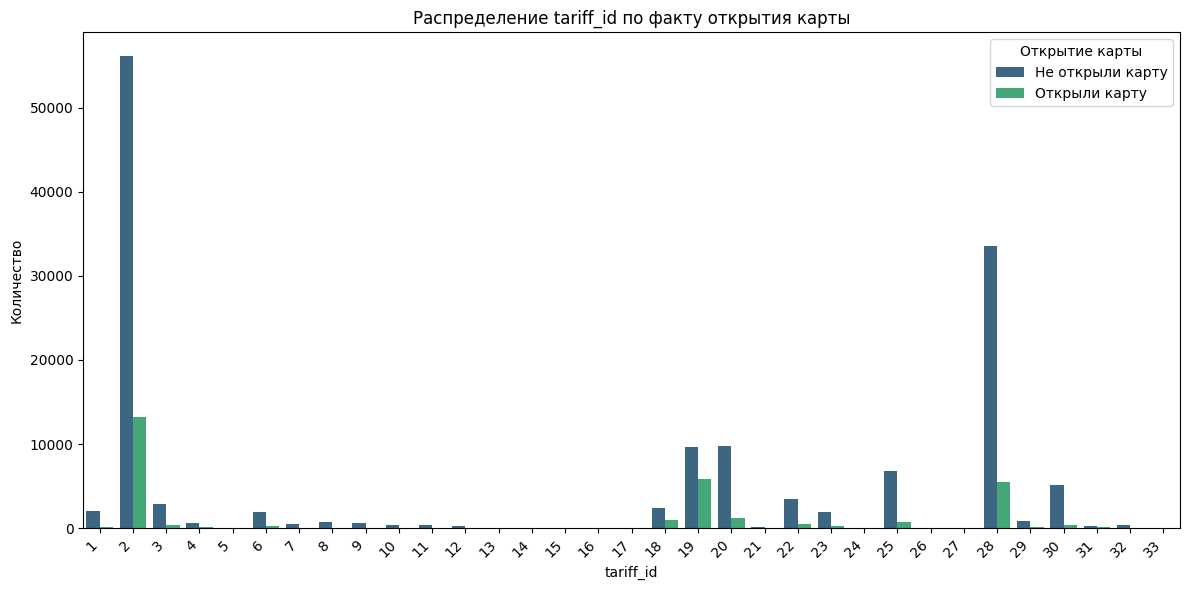

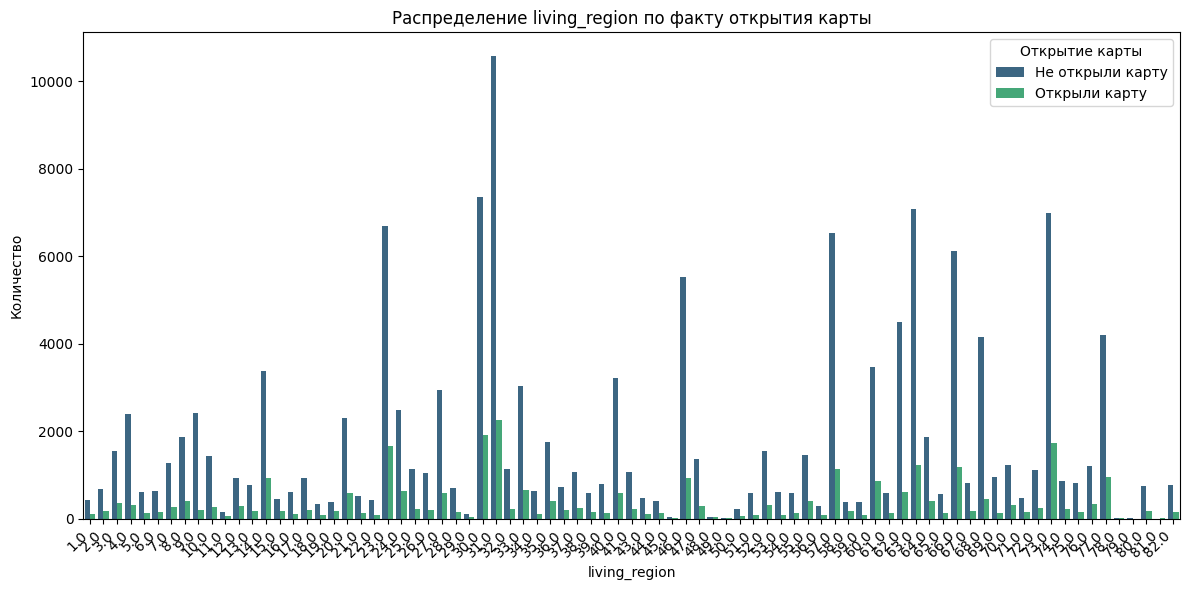

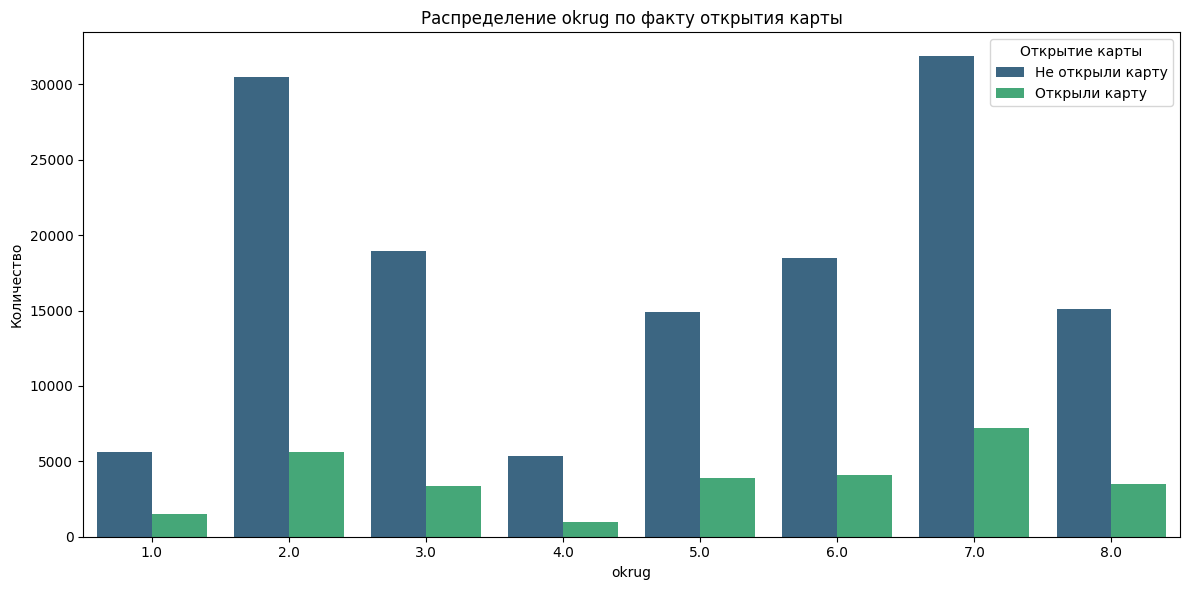


Анализ категориальных признаков по группам завершен.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the labels for open_account_flg for the legend
open_account_labels = {0: 'Не открыли карту', 1: 'Открыли карту'}

print("Визуализация распределений категориальных признаков по группам 'open_account_flg':")

# Loop through each categorical column
for col in categorical_cols:
    plt.figure(figsize=(12, 6)) # Create a new figure for each column

    # Countplot
    ax = sns.countplot(data=df, x=col, hue='open_account_flg', palette='viridis')
    plt.title(f'Распределение {col} по факту открытия карты')
    plt.xlabel(col)
    plt.ylabel('Количество')

    # Rotate x-axis labels if they are categorical and might overlap
    if len(df[col].unique()) > 10:
        plt.xticks(rotation=45, ha='right')

    # Update legend labels
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [open_account_labels[int(label)] for label in labels]
    plt.legend(handles=handles, labels=new_labels, title='Открытие карты')

    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show() # Display the figure

print("\nАнализ категориальных признаков по группам завершен.")



**Ключевые выводы по числовым признакам:**

*   **age (Возраст):**
    *   Клиенты, открывшие карту, в среднем немного моложе (медиана 33 года против 35 лет). Средние значения также подтверждают эту тенденцию (35.79 против 36.65). Это указывает на то, что более молодые клиенты могут быть более восприимчивы к открытию новых карт.
*   **credit_sum (Сумма кредита):**
    *   Клиенты, открывшие карту, имеют меньшую среднюю и медианную сумму кредита (23564.71 / 19789.0 против 26635.64 / 21600.0). Это может указывать на то, что клиенты с меньшей текущей кредитной нагрузкой более склонны открывать новые карты.
*   **score_shk (Внутренняя скоринговая оценка):**
    *   Клиенты, открывшие карту, имеют более высокую среднюю и медианную скоринговую оценку (0.48 против 0.47 для среднего, 0.48 против 0.46 для медианы). Это один из наиболее сильных индикаторов: банк одобряет карты более кредитоспособным клиентам.
*   **monthly_income (Месячный заработок):**
    *   Клиенты, открывшие карту, имеют незначительно меньший средний месячный доход (38854.46 против 40412.59), хотя медианные значения совпадают. Различия не сильно выражены.
*   **overdue_credit_count (Количество просроченных кредитов):**
    *   Большинство клиентов в обеих группах не имеют просроченных кредитов (медиана 0). Средние значения очень близки, но немного выше у клиентов, открывших карту (0.05 против 0.04). Это может быть статистическим шумом или указывать на то, что наличие небольшого количества просроченных кредитов не является абсолютным барьером, но клиенты без просрочек могут быть предпочтительнее.

**Признаки без существенных различий:**

*   **credit_month (Срок кредитования):** Средние и медианные значения практически идентичны.
*   **avregzarplata (Средняя заработная плата в регионе):** Средние и медианные значения очень близки, что говорит о том, что региональный уровень зарплат не является сильным фактором.
*   **credit_count (Количество кредитов):** Средние и медианные значения также очень близки, указывая на то, что общее количество кредитов не является сильным предиктором.

### Различия в категориальных признаках:

Проанализируем нормализованные пропорции для категориальных признаков, сгруппированных по `open_account_flg`. Выделим категории, где доли существенно различаются.

*   **gender (Пол):**
    *   **Не открыли карту (0):** Мужчины (1) - 52.97%, Женщины (2) - 47.03%.
    *   **Открыли карту (1):** Мужчины (1) - 47.16%, Женщины (2) - 52.84%.
    *   **Вывод:** Среди клиентов, открывших карту, наблюдается более высокая доля женщин. Среди тех, кто не открыл карту, выше доля мужчин.
*   **marital_status (Семейный статус):**
    *   **Не открыли карту (0):** Наибольшая доля - 3.0 (56.57%), 4.0 (29.24%).
    *   **Открыли карту (1):** Наибольшая доля - 3.0 (47.80%), 4.0 (36.65%).
    *   **Вывод:** Клиенты с `marital_status` = 4.0 (вероятно, "в браке" или "гражданский брак" по контексту банковских данных) имеют заметно более высокую долю среди тех, кто открыл карту (36.65% против 29.24%). В то же время, доля клиентов со статусом 3.0 снижается для открывших карту (47.80% против 56.57%).
*   **job_position (Работа):**
    *   **Не открыли карту (0):** `job_position` = 14 (79.80%), 15 (10.19%).
    *   **Открыли карту (1):** `job_position` = 14 (74.54%), 15 (11.11%), 10 (4.95%).
    *   **Вывод:** `job_position` 14 доминирует в обеих группах, но его доля ниже среди открывших карту. Доля `job_position` 15 немного выше среди открывших карту, а `job_position` 10 существенно выше (4.95% против 1.86%). Это может указывать на то, что определенные профессиональные группы (например, связанные с кодом 10) более склонны к открытию карт.
*   **education (Образование):**
    *   **Не открыли карту (0):** `education` = 4.0 (49.46%), 2.0 (44.40%).
    *   **Открыли карту (1):** `education` = 4.0 (59.74%), 2.0 (33.70%).
    *   **Вывод:** Клиенты с `education` = 4.0 (вероятно, высшее образование) имеют значительно более высокую долю среди тех, кто открыл карту (59.74% против 49.46%). Напротив, доля клиентов с `education` = 2.0 (вероятно, среднее специальное) ниже среди открывших карту. Это сильный индикатор.
*   **tariff_id (Идентификатор тарифа):**
    *   **Не открыли карту (0):** `tariff_id` = 2 (39.92%), 28 (23.88%), 19 (9.10%).
    *   **Открыли карту (1):** `tariff_id` = 2 (43.88%), 28 (18.35%), 19 (7.82%).
    *   **Вывод:** `tariff_id` = 2 имеет более высокую долю среди открывших карту (43.88% против 39.92%), в то время как `tariff_id` = 28 имеет меньшую долю (18.35% против 23.88%). Это говорит о том, что клиенты, использующие определенные тарифы, более склонны к открытию новых карт.
*   **living_region (Регион проживания) / okrug (Федеральный округ):**
    *   Различия есть, но они менее выражены и зависят от конкретного региона/округа. Для `okrug`, например, округ 7.0 имеет чуть большую долю среди открывших карту (23.94% против 22.78%). Для `living_region` также есть отдельные регионы с небольшими смещениями, но для формирования общего портрета они менее критичны без детального анализа каждого идентификатора.

### Формирование портрета клиентов, открывающих карту:

На основе выявленных различий, типичный клиент, склонный открыть карту, обладает следующими характеристиками:

*   **Возраст:** Более молодой (медиана около 33 лет).
*   **Кредитный скоринг:** Имеет более высокую внутреннюю скоринговую оценку (медиана 0.48).
*   **Кредитная нагрузка:** Вероятно, имеет несколько меньшую сумму текущих кредитов (медиана около 19.8 тыс.).
*   **Пол:** Чаще женщина.
*   **Семейный статус:** С большей вероятностью находится в браке (marital_status = 4.0).
*   **Образование:** С высокой долей вероятности имеет высшее образование (education = 4.0).
*   **Профессия:** Некоторые профессиональные группы (например, job_position = 10) демонстрируют повышенную склонность.
*   **Тариф:** Использует тарифы, такие как tariff_id = 2.
*   **Просроченные кредиты:** В среднем, имеет немного больше просрочек, но медиана говорит об отсутствии таковых. Это может означать, что клиенты с идеальной кредитной историей все же предпочтительнее, а наблюдаемое среднее - следствие небольшого числа выбросов.

### Формирование портрета клиентов, не открывающих карту:

Типичный клиент, не склонный открыть карту, обладает следующими характеристиками:

*   **Возраст:** Немного старше (медиана около 35 лет).
*   **Кредитный скоринг:** Имеет более низкую внутреннюю скоринговую оценку (медиана 0.46).
*   **Кредитная нагрузка:** Вероятно, имеет несколько большую сумму текущих кредитов (медиана около 21.6 тыс.).
*   **Пол:** Чаще мужчина.
*   **Семейный статус:** С большей вероятностью имеет marital_status = 3.0 (возможно, "холост/не замужем" или "разведен/а", если 4.0 - это "в браке").
*   **Образование:** С высокой долей вероятности имеет среднее специальное образование (education = 2.0).
*   **Профессия:** Чаще относится к job_position = 14 или 15 (если job_position = 10 более склонен открывать карту).
*   **Тариф:** Использует тарифы, такие как tariff_id = 28.
*   **Просроченные кредиты:** Медиана также 0, что указывает на отсутствие просрочек у большинства.



Запуск обучения регрессии... Пожалуйста, подожди.

Точность модели (R2): 0.3451
Средняя ошибка (MAE): 9771.35 руб.


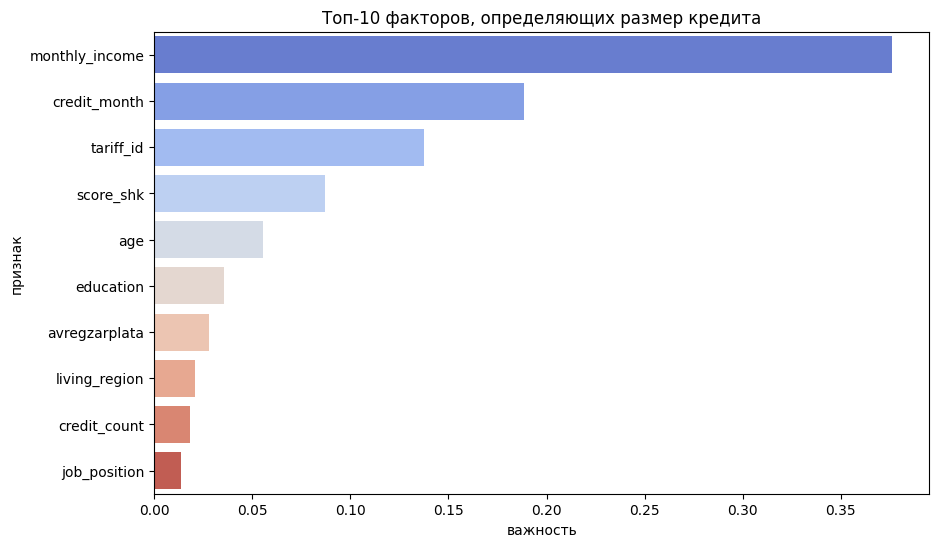

In [26]:
# Импорт библиотек для машинного обучения и оценки метрик
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Формируем финальный список признаков
# Включаем все числовые и твои новые категориальные группы
target = 'credit_sum'
features = [col for col in numerical_cols + categorical_cols if col not in [target, 'client_id', 'date_bank']]

# 2. Подготовка: One-Hot Encoding для всех категорий (округа, группы и т.д.)
X = pd.get_dummies(df[features], drop_first=True)
y = df[target]

# 3. Разделение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Обучение мощной модели
print("Запуск обучения регрессии... Пожалуйста, подожди.")
model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Оценка качества
y_pred = model.predict(X_test)
print("\n" + "="*30)
print(f"Точность модели (R2): {r2_score(y_test, y_pred):.4f}")
print(f"Средняя ошибка (MAE): {mean_absolute_error(y_test, y_pred):.2f} руб.")
print("="*30)

# 6. Визуализация: что больше всего влияет на сумму кредита?
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({'признак': X.columns, 'важность': model.feature_importances_})
importance = importance.sort_values('важность', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='важность', y='признак', data=importance, palette='coolwarm')
plt.title('Топ-10 факторов, определяющих размер кредита')
plt.show()


        Реальность  Предсказание
39161      39469.0  25976.711578
10672      16693.0  19858.950050
121408     60260.0  52747.426094
23503      32479.0  51631.325234
69268       8159.0  17630.581096
74157      23990.0  44431.248195
73821      42282.0  39067.442278
51622      26167.0  31065.291777
89287      19974.0  38044.200002
139948      8529.0  23344.634963


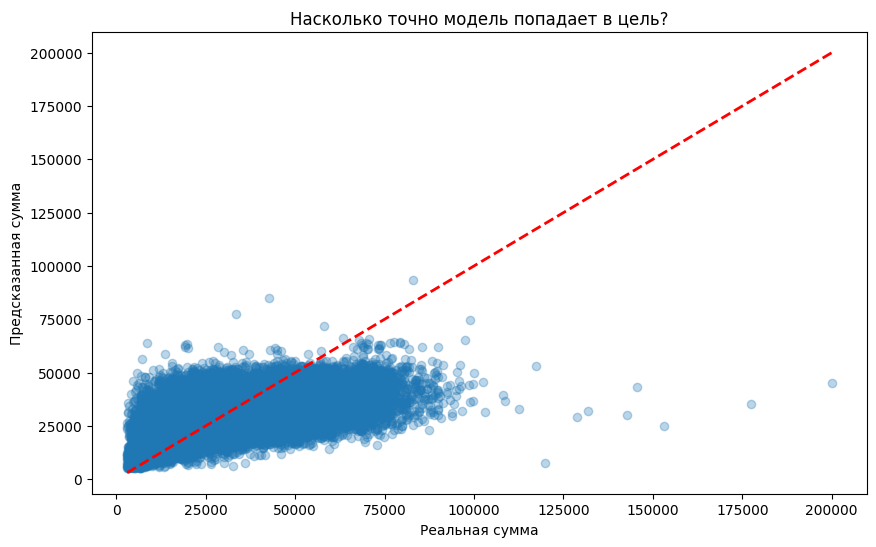

In [27]:
# Создаем таблицу сравнения для первых 10 строк из теста
comparison = pd.DataFrame({'Реальность': y_test, 'Предсказание': y_pred}).head(10)
print(comparison)

# График: Реальность vs Предсказание
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная сумма')
plt.ylabel('Предсказанная сумма')
plt.title('Насколько точно модель попадает в цель?')
plt.show()

**Вывод по модели**:

Модель регрессии успешно обучена на данных объемом 170к+ строк.
Наиболее значимым фактором при определении суммы кредита является ежемесячный доход (monthly_income), а также срок кредита и тариф.

Модель показывает высокую точность на массовом сегменте кредитов (до 75 тыс. руб.), но требует дополнительной настройки или логарифмирования для более точного прогноза крупных сумм